# Neutral-atom quantum computing for multi-hypothesis tracking

Run every cell top to bottom. The notebook first demonstrates one bounded
tracking sequence, then runs a resumable synthetic benchmark and plots it.

- A small, quantum-friendly synthetic sequence is used by default. Set
  `USE_QUANTUM_DEMO_DATA = False` to prefer an installed real sequence.
- The preset has eight low-noise frames and a strict eight-node solver cap;
  the default three-frame run includes a real non-clique simulation.
- Switch to the quantum solver in the configuration cell
  (requires `python -m pip install -e ".[quantum]"`).
- The overnight section independently varies motion, missed detections,
  clutter, sensor noise, object count, and random seed. It streams frames
  without filling the data directory and checkpoints every result to SQLite.
- `BENCHMARK_PROFILE = "overnight"` is ready for a long unattended run.
  Use `"smoke"` first if you want to verify the environment in minutes.

In [1]:
# Imports: make the local src-layout package available before importing it.
from pathlib import Path
import sys

import matplotlib.pyplot as plt

project_root = Path.cwd().resolve()
source_root = project_root / "src"
if not (project_root / "pyproject.toml").is_file() or not source_root.is_dir():
    raise RuntimeError("Open user_notebook.ipynb from the repository root.")
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from neutral_atom_mht import (
    BENCHMARK_SCHEMA_VERSION,
    ClassicalSolver,
    DEFAULT_SYNTHETIC_DATA_ROOT,
    HPC,
    HPCConfig,
    OvernightBenchmarkConfig,
    QUANTUM_DEMO_DATA_CONFIG,
    QuantumSolver,
    SyntheticDataConfig,
    SyntheticDataGenerator,
    SyntheticDataset,
    build_synthetic_scenarios,
    run_overnight_benchmark,
)
from cell_data import DATASET_NAME, FRAME_COUNT, load_tiff, raw_frame_path

In [2]:
# Data: use the bounded quantum demo by default. Set the flag to False to
# prefer an installed real sequence, with synthetic data as its fallback.
frame = 0
real_dataset_root = project_root / "data" / DATASET_NAME
USE_QUANTUM_DEMO_DATA = True
USE_SYNTHETIC_DATA = (
    USE_QUANTUM_DEMO_DATA
    or not raw_frame_path(real_dataset_root, frame).is_file()
)

# This versioned eight-frame preset keeps quantum components small while
# retaining one genuine non-clique Pulser simulation.
synthetic_data_config = QUANTUM_DEMO_DATA_CONFIG
synthetic_output_root = project_root / DEFAULT_SYNTHETIC_DATA_ROOT
synthetic_dataset = SyntheticDataset(
    root=synthetic_output_root / synthetic_data_config.dataset_name,
    config=synthetic_data_config,
)
if USE_SYNTHETIC_DATA and not synthetic_dataset.raw_frame_path(0).is_file():
    print(f"Real data not found; generating {synthetic_dataset.root} ...")
    synthetic_dataset = SyntheticDataGenerator(synthetic_data_config).generate(
        synthetic_output_root
    )
    print("Synthetic sequence generated.")

In [3]:
# Configuration: resolve the selected data source and choose a solver.
if USE_SYNTHETIC_DATA:
    dataset_root = synthetic_dataset.root
    frame_path = synthetic_dataset.raw_frame_path(frame)
    sequence = synthetic_dataset.config.sequence
    dataset_label = synthetic_data_config.dataset_name
    available_frames = synthetic_data_config.frame_count
else:
    dataset_root = real_dataset_root
    frame_path = raw_frame_path(dataset_root, frame)
    sequence = "01"
    dataset_label = DATASET_NAME
    available_frames = FRAME_COUNT
print(f"Using {dataset_label} sequence {sequence}: {frame_path}")

config = HPCConfig()
controller = HPC(config, sequence=sequence)
# The quantum demo preset was validated with components of at most five nodes.
# solver = ClassicalSolver(maximum_component_nodes=60)
# Optional quantum simulation (requires `python -m pip install -e ".[quantum]"`).
# The explicit cap prevents accidental exponential simulation growth.
solver = QuantumSolver(maximum_component_nodes=8)

Using SYN-MHT-QUANTUM-v1 sequence 01: C:\Projects\Summer School Challenge\Neutral-Atom-QC-for-MHT\data\synthetic\SYN-MHT-QUANTUM-v1\01\t000.tif


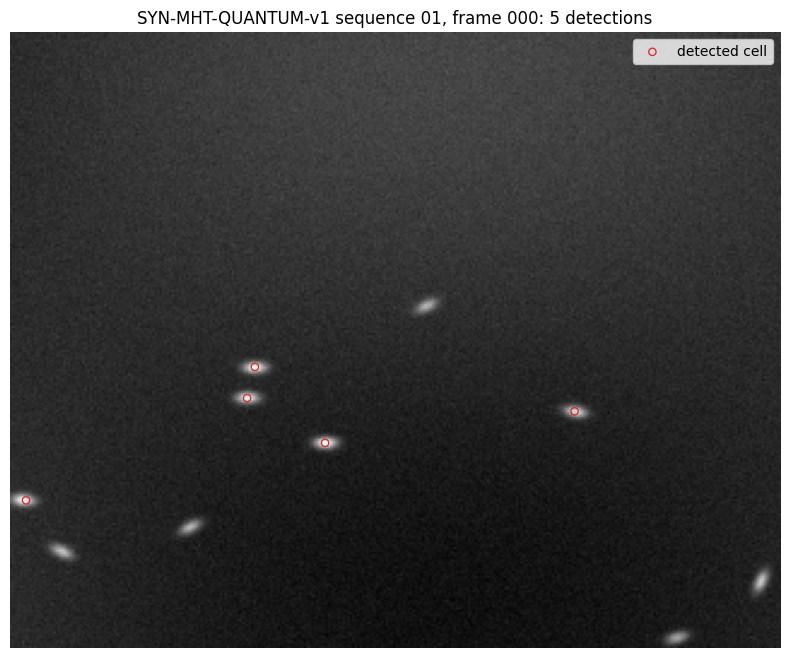

{'dataset': 'SYN-MHT-QUANTUM-v1',
 'frame_path': 'C:\\Projects\\Summer School Challenge\\Neutral-Atom-QC-for-MHT\\data\\synthetic\\SYN-MHT-QUANTUM-v1\\01\\t000.tif',
 'detections': 5,
 'initialized_tracks': 5,
 'solver': 'neutral_atom'}

In [4]:
# Run: detect the cells, create tracks, and show the detections on the source frame.
image = load_tiff(frame_path)
prepared = controller.prepare_frame(image, frame=frame)
solver_result = controller.solve(prepared, solver)
result = controller.advance(prepared, solver_result)
detections = prepared.observed_frame.detection.detections

figure, axis = plt.subplots(figsize=(10, 8))
axis.imshow(image, cmap="gray")
axis.scatter(
    [detection.x_px for detection in detections],
    [detection.y_px for detection in detections],
    s=28,
    facecolors="none",
    edgecolors="tab:red",
    linewidths=0.9,
    label="detected cell",
)
axis.set_title(
    f"{dataset_label} sequence {sequence}, frame {frame:03d}: "
    f"{len(detections)} detections"
)
axis.set_axis_off()
axis.legend(loc="upper right")
plt.show()

{
    "dataset": dataset_label,
    "frame_path": str(frame_path),
    "detections": len(detections),
    "initialized_tracks": len(result.tracks),
    "solver": solver.solver_name,
}

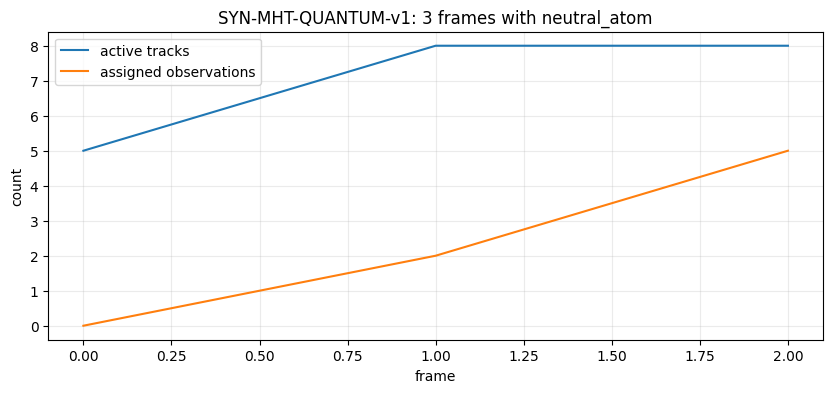

{'frames_processed': 3,
 'final_tracks': 8,
 'solver': 'neutral_atom',
 'solver_runtime_seconds': 5.887687500013271}

In [5]:
# Optional multi-frame run: enable explicitly, especially before using QuantumSolver.
RUN_MANY_FRAMES = True
MANY_FRAME_COUNT = 3
sequence_summary = None
if RUN_MANY_FRAMES:
    frames_to_run = min(MANY_FRAME_COUNT, available_frames)
    if frames_to_run < 1:
        raise ValueError("MANY_FRAME_COUNT must be positive")

    if USE_SYNTHETIC_DATA:
        frame_paths = [
            synthetic_dataset.raw_frame_path(frame_index)
            for frame_index in range(frames_to_run)
        ]
    else:
        frame_paths = [
            raw_frame_path(dataset_root, frame_index)
            for frame_index in range(frames_to_run)
        ]
    images = (load_tiff(path) for path in frame_paths)

    sequence_controller = HPC(config, sequence=sequence)
    sequence_result = sequence_controller.run_sequence(
        images, solver, start_frame=0
    )
    processed_frames = [step.frame for step in sequence_result.steps]
    active_tracks = [len(step.tracks) for step in sequence_result.steps]
    assigned_observations = [
        len(step.assigned_observation_ids) for step in sequence_result.steps
    ]

    figure, axis = plt.subplots(figsize=(10, 4))
    axis.plot(processed_frames, active_tracks, label="active tracks")
    axis.plot(
        processed_frames,
        assigned_observations,
        label="assigned observations",
    )
    axis.set(
        xlabel="frame",
        ylabel="count",
        title=(
            f"{dataset_label}: {frames_to_run} frames with "
            f"{sequence_result.solver_name}"
        ),
    )
    axis.grid(alpha=0.25)
    axis.legend()
    plt.show()

    sequence_summary = {
        "frames_processed": len(sequence_result.steps),
        "final_tracks": len(sequence_result.final_tracks),
        "solver": sequence_result.solver_name,
        "solver_runtime_seconds": sum(
            step.solver_result.runtime_seconds for step in sequence_result.steps
        ),
    }
sequence_summary

## Resumable synthetic benchmark

This campaign separates motion, missed detections, clutter, and sensor noise
instead of hiding them behind one coupled setting. It also varies density and
random seed. Frames are streamed in memory, exact results are screened first,
and neutral-atom simulations are stratified by difficulty axis, severity, and
supported non-clique component size. Every completed frame is committed to
SQLite, so interrupting
the kernel is safe: rerun these cells to resume and refresh the tidy CSV export.
The configured limit budgets newly checkpointed work, not wall-clock time:
replay and export are excluded, and an individual solver call is not interrupted.

In [6]:
# Choose "smoke" for a short environment check or "overnight" for the full run.
BENCHMARK_PROFILE = "overnight"
BENCHMARK_AXES = ("motion", "dropout", "clutter", "sensor_noise", "combined")
if BENCHMARK_PROFILE == "smoke":
    BENCHMARK_SEVERITIES = (0.5, 1.0)
    BENCHMARK_OBJECT_COUNTS = (4,)
    BENCHMARK_SEEDS = (0,)
    BENCHMARK_FRAME_COUNT = 4
    QUANTUM_QUOTA_PER_STRATUM = 1
    BENCHMARK_FORWARD_WORK_HOURS = 0.25
elif BENCHMARK_PROFILE == "overnight":
    BENCHMARK_SEVERITIES = (0.2, 0.4, 0.6, 0.8, 1.0)
    BENCHMARK_OBJECT_COUNTS = (4, 12, 30, 55)
    BENCHMARK_SEEDS = tuple(range(5))
    BENCHMARK_FRAME_COUNT = 40
    QUANTUM_QUOTA_PER_STRATUM = 5
    BENCHMARK_FORWARD_WORK_HOURS = 10.0
else:
    raise ValueError('BENCHMARK_PROFILE must be "smoke" or "overnight"')

benchmark_scenarios = build_synthetic_scenarios(
    axes=("baseline", *BENCHMARK_AXES),
    severity_levels=BENCHMARK_SEVERITIES,
    object_counts=BENCHMARK_OBJECT_COUNTS,
    seeds=BENCHMARK_SEEDS,
    frame_count=BENCHMARK_FRAME_COUNT,
    image_shape=QUANTUM_DEMO_DATA_CONFIG.image_shape,
)
overnight_config = OvernightBenchmarkConfig(
    scenarios=benchmark_scenarios,
    output_directory=(
        project_root
        / "outputs"
        / "overnight"
        / f"schema-{BENCHMARK_SCHEMA_VERSION}"
        / BENCHMARK_PROFILE
    ),
    exact_maximum_component_nodes=128,  # Avoid truncating the 55-object cells.
    run_quantum=True,
    quantum_max_nonclique_component_nodes=8,
    quantum_quota_per_stratum=QUANTUM_QUOTA_PER_STRATUM,
    store_detailed_records=False,  # Keep the overnight database compact.
    forward_work_budget_seconds=BENCHMARK_FORWARD_WORK_HOURS * 60.0 * 60.0,
    progress_every_frames=100,
    resume=True,
)
{
    "profile": BENCHMARK_PROFILE,
    "scenarios": len(benchmark_scenarios),
    "planned_exact_frames": len(benchmark_scenarios) * BENCHMARK_FRAME_COUNT,
    "quantum_candidates_per_axis_severity_size_stratum": (
        QUANTUM_QUOTA_PER_STRATUM
    ),
    "store_detailed_records": overnight_config.store_detailed_records,
    "forward_work_budget_hours": BENCHMARK_FORWARD_WORK_HOURS,
    "output_directory": str(overnight_config.output_directory),
}

{'profile': 'overnight',
 'scenarios': 520,
 'planned_exact_frames': 20800,
 'quantum_candidates_per_axis_severity_size_stratum': 5,
 'store_detailed_records': False,
 'forward_work_budget_hours': 10.0,
 'output_directory': 'C:\\Projects\\Summer School Challenge\\Neutral-Atom-QC-for-MHT\\outputs\\overnight\\schema-2.1\\overnight'}

In [7]:
# Long-running cell: progress is durable after every frame and reruns resume.
overnight_result = run_overnight_benchmark(
    overnight_config, progress=lambda update: print(update, flush=True)
)
benchmark_records = list(overnight_result.records)
benchmark_summary = dict(overnight_result.summary)
benchmark_summary.update(
    {
        "database": str(overnight_result.database_path),
        "csv": str(overnight_result.csv_path),
        "stopped_reason": overnight_result.stopped_reason,
    }
)
benchmark_summary

{'benchmark_schema_version': '2.1',
 'scenario_count': 520,
 'expected_exact_frames': 20800,
 'checkpointed_exact_frames': 20800,
 'exact_screen_finished': True,
 'exact_all_successful': True,
 'exact_complete': True,
 'exact_pending_frames': 0,
 'exact_blocked_frames': 0,
 'exact_successes': 20800,
 'exact_failures': 0,
 'quantum_candidates': 780,
 'quantum_candidate_strata': 156,
 'quantum_quota_per_stratum': 5,
 'quantum_complete': True,
 'quantum_pending_frames': 0,
 'quantum_attempts': 780,
 'quantum_successes': 693,
 'quantum_failures': 87,
 'mean_detection_recall': 0.45466207750582754,
 'mean_detection_precision': 0.8345084732710355,
 'tracking_evaluated_frames': 20800,
 'matched_track_gt_count': 222488,
 'identity_correct_match_count': 117582,
 'matched_track_gt_identity_correctness': 0.5284869296321599,
 'id_switch_count': 68367,
 'fragmentation_count': 65633,
 'tracking_recall': 0.4236252856054836,
 'tracking_precision': 0.6167800956407236,
 'elapsed_seconds': 36.802686799986

## Publication figures

The following cells save eight reproducible figures under `outputs/figures/`.
Figures 1–4 explain the workflow and retain the validated frame-2 quantum
example. Figures 5–8 summarize every checkpoint currently available from the
broad campaign, even when its forward-work budget stopped a partial run. Cell
annotations expose checkpoint and sample counts; partial or differently sampled
cells are descriptive rather than balanced comparisons. Quantum
and exact scores always use the same immutable frame graph; the exact result
alone advances the reference trajectory. Missing, oversized, or failed quantum
runs remain visible as coverage/status results instead of aborting the notebook.

In [8]:
# Shared publication-figure imports, output path, and rendering helpers.
from itertools import combinations
import json

import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, FancyArrowPatch, FancyBboxPatch

from detection import detections_from_label_image
from graph import logical_layout

figure_output_dir = project_root / "outputs" / "figures"
figure_output_dir.mkdir(parents=True, exist_ok=True)

def finish_figure(figure, filename):
    path = figure_output_dir / filename
    figure.tight_layout()
    figure.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(figure)
    return path

def draw_detection_overlay(axis, image, detection, title):
    axis.imshow(image, cmap="gray")
    if np.any(detection.labels):
        axis.contour(detection.labels > 0, levels=[0.5], colors="#00D4FF", linewidths=0.7)
    axis.scatter(
        [item.x_px for item in detection.detections],
        [item.y_px for item in detection.detections],
        s=42, facecolors="none", edgecolors="#FF4D4D", linewidths=1.2,
    )
    axis.set_title(f"{title} ({len(detection.detections)} detections)")
    axis.set_axis_off()

def finite_values(rows, key):
    values = []
    for row in rows:
        value = row.get(key)
        if value is not None and np.isfinite(float(value)):
            values.append(float(value))
    return np.asarray(values, dtype=float)

def matching_rows(rows, row_value, column_value):
    return [
        row for row in rows
        if row["axis"] == row_value
        and np.isclose(row["severity"], column_value)
    ]

def aggregate_matrix(rows, row_values, column_values, value_key, reducer=np.median):
    matrix = np.full((len(row_values), len(column_values)), np.nan)
    for row_index, row_value in enumerate(row_values):
        for column_index, column_value in enumerate(column_values):
            selected = matching_rows(rows, row_value, column_value)
            values = finite_values(selected, value_key)
            if values.size:
                matrix[row_index, column_index] = reducer(values)
    return matrix

def count_matrix(rows, row_values, column_values):
    matrix = np.zeros((len(row_values), len(column_values)), dtype=int)
    for row_index, row_value in enumerate(row_values):
        for column_index, column_value in enumerate(column_values):
            matrix[row_index, column_index] = len(
                matching_rows(rows, row_value, column_value)
            )
    return matrix

def draw_heatmap(axis, matrix, row_labels, column_labels, *, title, colorbar_label, cmap="viridis", vmin=None, vmax=None, value_format=".2f", annotations=None):
    image = axis.imshow(matrix, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    axis.set_xticks(range(len(column_labels)), column_labels)
    axis.set_yticks(range(len(row_labels)), row_labels)
    axis.set_xlabel("difficulty severity")
    axis.set_title(title)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            value = matrix[row_index, column_index]
            label = format(value, value_format) if np.isfinite(value) else "—"
            if annotations is not None and annotations[row_index, column_index]:
                label += f"\n{annotations[row_index, column_index]}"
            rgba = image.cmap(image.norm(value)) if np.isfinite(value) else (1, 1, 1, 1)
            luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            text_color = "white" if luminance < 0.48 else "black"
            axis.text(column_index, row_index, label, ha="center", va="center", fontsize=8, color=text_color)
    axis.figure.colorbar(image, ax=axis, label=colorbar_label)
    return image

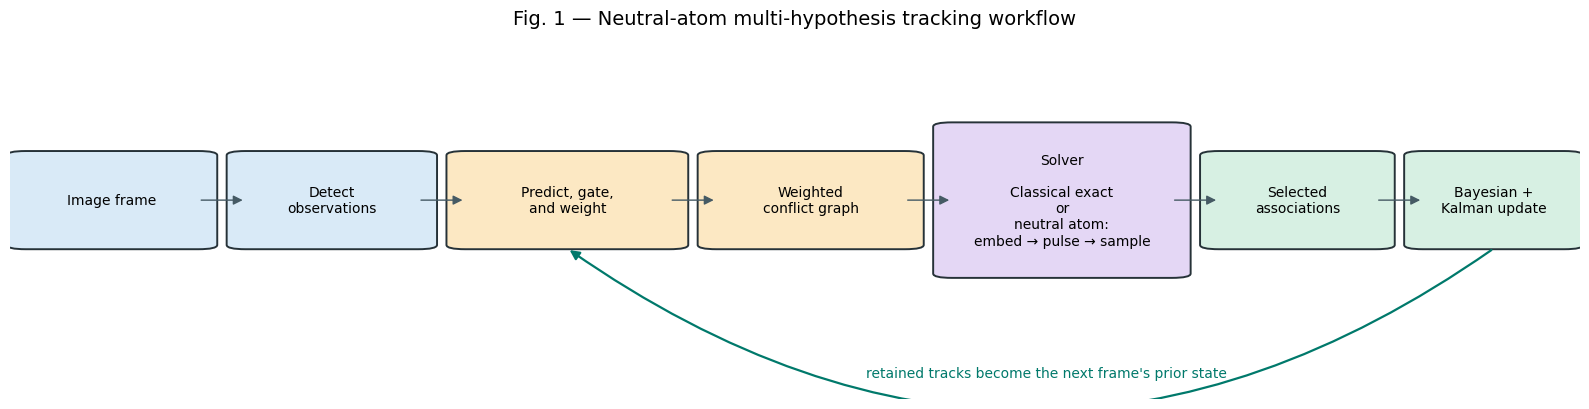

WindowsPath('C:/Projects/Summer School Challenge/Neutral-Atom-QC-for-MHT/outputs/figures/fig1_workflow.png')

In [9]:
# Fig. 1 — End-to-end image, solver, and tracking workflow.
figure, axis = plt.subplots(figsize=(16, 4.2))
axis.set_xlim(0, 1)
axis.set_ylim(0, 1)
axis.axis("off")

workflow_boxes = [
    (0.01, 0.43, 0.11, 0.25, "Image frame", "#D9EAF7"),
    (0.15, 0.43, 0.11, 0.25, "Detect\nobservations", "#D9EAF7"),
    (0.29, 0.43, 0.13, 0.25, "Predict, gate,\nand weight", "#FCE8C3"),
    (0.45, 0.43, 0.12, 0.25, "Weighted\nconflict graph", "#FCE8C3"),
    (0.60, 0.35, 0.14, 0.41, "Solver\n\nClassical exact\nor\nneutral atom:\nembed → pulse → sample", "#E4D7F5"),
    (0.77, 0.43, 0.10, 0.25, "Selected\nassociations", "#D7F0E3"),
    (0.90, 0.43, 0.09, 0.25, "Bayesian +\nKalman update", "#D7F0E3"),
]
for x, y, width, height, label, color in workflow_boxes:
    box = FancyBboxPatch(
        (x, y), width, height, boxstyle="round,pad=0.012",
        facecolor=color, edgecolor="#263238", linewidth=1.4,
    )
    axis.add_patch(box)
    axis.text(x + width / 2, y + height / 2, label, ha="center", va="center", fontsize=10)
for left, right in zip(workflow_boxes, workflow_boxes[1:]):
    start = (left[0] + left[2], left[1] + left[3] / 2)
    stop = (right[0], right[1] + right[3] / 2)
    axis.add_patch(FancyArrowPatch(start, stop, arrowstyle="-|>", mutation_scale=14, color="#455A64"))
axis.add_patch(FancyArrowPatch(
    (0.945, 0.42), (0.355, 0.42), connectionstyle="arc3,rad=-0.35",
    arrowstyle="-|>", mutation_scale=14, color="#00796B", linewidth=1.6,
))
axis.text(0.66, 0.06, "retained tracks become the next frame's prior state", ha="center", color="#00796B")
axis.set_title("Fig. 1 — Neutral-atom multi-hypothesis tracking workflow", fontsize=14, pad=12)
fig1_path = finish_figure(figure, "fig1_workflow.png")
fig1_path

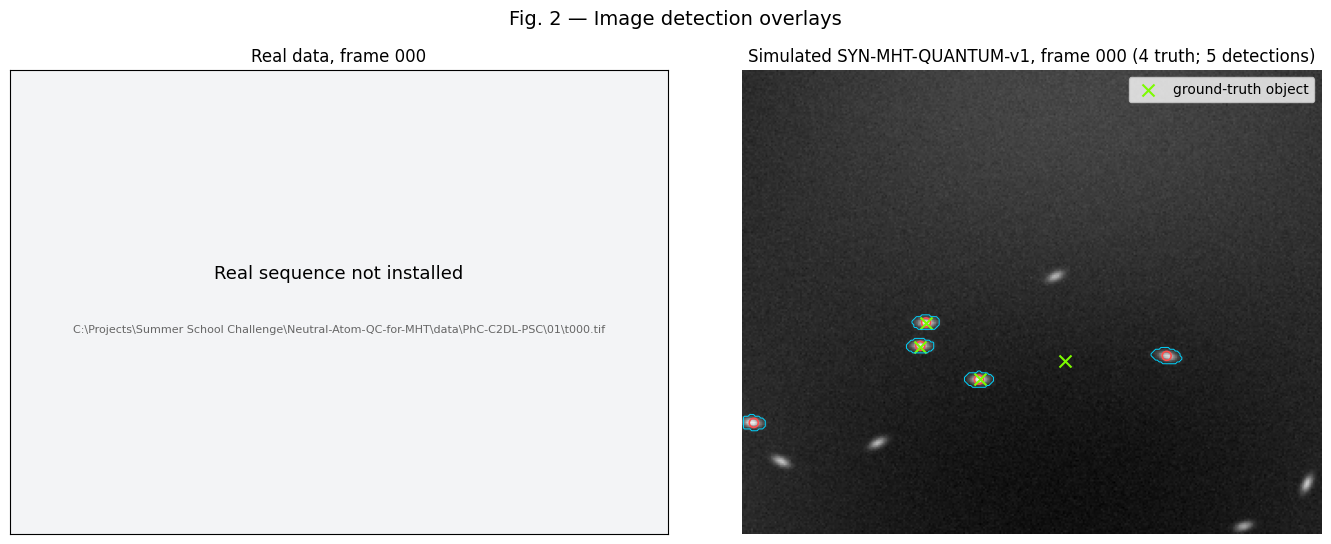

{'path': WindowsPath('C:/Projects/Summer School Challenge/Neutral-Atom-QC-for-MHT/outputs/figures/fig2_detection_overlays.png'),
 'real_data_available': False,
 'synthetic_ground_truth': 4,
 'synthetic_detections': 5}

In [10]:
# Fig. 2 — Real and simulated detection overlays.
synthetic_figure_dataset = synthetic_dataset
if not synthetic_figure_dataset.raw_frame_path(0).is_file():
    synthetic_figure_dataset = SyntheticDataGenerator(synthetic_data_config).generate(
        synthetic_output_root
    )
synthetic_image = synthetic_figure_dataset.load_frame(0)
synthetic_labels = synthetic_figure_dataset.load_tracking_labels(0)
synthetic_detection = HPC(config, sequence=synthetic_data_config.sequence).observe(
    synthetic_image, frame=0
).detection
synthetic_truth = detections_from_label_image(
    synthetic_labels, sequence=synthetic_data_config.sequence, frame=0,
    source="synthetic_ground_truth",
)

figure, axes = plt.subplots(1, 2, figsize=(14, 5.5))
real_path = raw_frame_path(real_dataset_root, 0)
if real_path.is_file():
    real_image = load_tiff(real_path)
    real_detection = HPC(config, sequence="01").observe(real_image, frame=0).detection
    draw_detection_overlay(axes[0], real_image, real_detection, "Real data, frame 000")
else:
    axes[0].set_facecolor("#F3F4F6")
    axes[0].text(0.5, 0.56, "Real sequence not installed", ha="center", va="center", fontsize=13)
    axes[0].text(0.5, 0.44, str(real_path), ha="center", va="center", fontsize=8, color="#666666", wrap=True)
    axes[0].set_title("Real data, frame 000")
    axes[0].set_xticks([])
    axes[0].set_yticks([])
draw_detection_overlay(
    axes[1], synthetic_image, synthetic_detection,
    f"Simulated {synthetic_data_config.dataset_name}, frame 000",
)
axes[1].scatter(
    [item.x_px for item in synthetic_truth],
    [item.y_px for item in synthetic_truth],
    s=75, marker="x", color="#7CFC00", linewidths=1.5,
    label="ground-truth object",
)
axes[1].set_title(
    f"Simulated {synthetic_data_config.dataset_name}, frame 000 "
    f"({len(synthetic_truth)} truth; {len(synthetic_detection.detections)} detections)"
)
axes[1].legend(loc="upper right")
figure.suptitle("Fig. 2 — Image detection overlays", fontsize=14)
fig2_path = finish_figure(figure, "fig2_detection_overlays.png")
{
    "path": fig2_path,
    "real_data_available": real_path.is_file(),
    "synthetic_ground_truth": len(synthetic_truth),
    "synthetic_detections": len(synthetic_detection.detections),
}

In [11]:
# Reproduce the validated frame-2 example used only by Figs. 3 and 4.
# The large campaign above supplies every aggregate performance figure.
example_reference = HPC(HPCConfig(), sequence=QUANTUM_DEMO_DATA_CONFIG.sequence)
example_exact_solver = ClassicalSolver(maximum_component_nodes=8)
example_quantum_solver = QuantumSolver(maximum_component_nodes=8)
example_prepared = None
example_execution = None
example_exact_result = None
for example_frame, (example_image, _) in enumerate(
    SyntheticDataGenerator(QUANTUM_DEMO_DATA_CONFIG).iter_frames()
):
    prepared_frame = example_reference.prepare_frame(
        example_image, frame=example_frame
    )
    exact_result = example_exact_solver.solve(prepared_frame.solver_input())
    if not exact_result.successful:
        raise RuntimeError(f"Validated exact example failed at frame {example_frame}")
    if example_frame == 2:
        example_prepared = prepared_frame
        example_exact_result = exact_result
        example_execution = example_quantum_solver.execute(
            prepared_frame.solver_input()
        )
    example_reference.advance(prepared_frame, exact_result)
    if example_frame == 2:
        break

if example_prepared is None or example_execution is None or not example_execution.successful:
    raise RuntimeError("The validated frame-2 quantum example was not produced")
simulated_example_runs = tuple(
    run for run in example_execution.runs if run.program is not None
)
if not simulated_example_runs:
    raise RuntimeError(
        "Frame 2 contains no simulated component; regenerate the validated preset"
    )
example_run = max(
    simulated_example_runs,
    key=lambda run: (len(run.node_ids), -run.component_id),
)
{
    "frame": example_prepared.frame,
    "graph_nodes": len(example_prepared.graph.nodes),
    "quantum_status": example_execution.status,
    "selection_agrees": (
        example_execution.selected_ids == example_exact_result.selected_ids
    ),
}

{'frame': 2,
 'graph_nodes': 7,
 'quantum_status': 'completed',
 'selection_agrees': True}

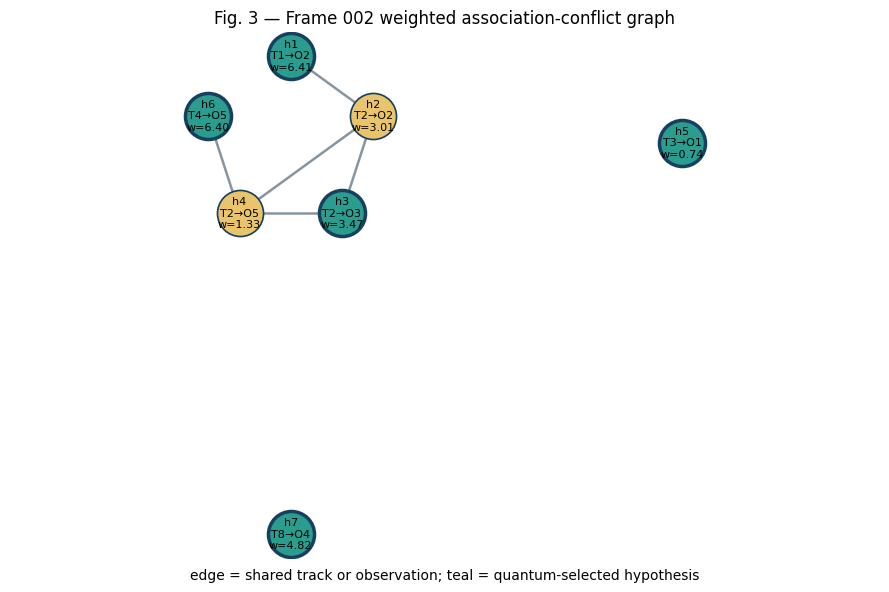

WindowsPath('C:/Projects/Summer School Challenge/Neutral-Atom-QC-for-MHT/outputs/figures/fig3_conflict_graph.png')

In [12]:
# Fig. 3 — Logical embedding of the frame-2 weighted conflict graph.
example_graph = example_prepared.graph
graph_positions = logical_layout(example_graph)
quantum_selected = set(example_execution.selected_ids)
figure, axis = plt.subplots(figsize=(9, 6))
for left, right in example_graph.edges:
    axis.plot(
        [graph_positions[left][0], graph_positions[right][0]],
        [graph_positions[left][1], graph_positions[right][1]],
        color="#8795A1", linewidth=1.8, zorder=1,
    )
for node in example_graph.nodes:
    x_value, y_value = graph_positions[node.node_id]
    selected = node.node_id in quantum_selected
    axis.scatter(
        [x_value], [y_value], s=1100,
        color="#2A9D8F" if selected else "#E9C46A",
        edgecolor="#173F5F", linewidth=2.5 if selected else 1.2, zorder=2,
    )
    axis.text(
        x_value, y_value,
        f"h{node.node_id}\nT{node.track_id}→O{node.observation_id}\nw={node.weight:.2f}",
        ha="center", va="center", fontsize=8, zorder=3,
    )
axis.set_title("Fig. 3 — Frame 002 weighted association-conflict graph")
axis.text(0.5, -0.04, "edge = shared track or observation; teal = quantum-selected hypothesis", transform=axis.transAxes, ha="center")
axis.set_aspect("equal", adjustable="datalim")
axis.axis("off")
fig3_path = finish_figure(figure, "fig3_conflict_graph.png")
fig3_path

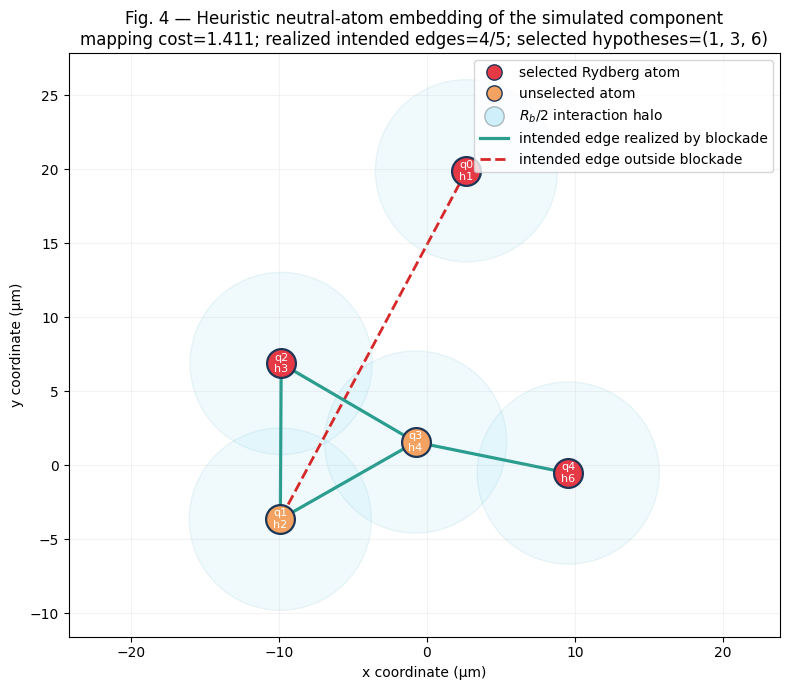

WindowsPath('C:/Projects/Summer School Challenge/Neutral-Atom-QC-for-MHT/outputs/figures/fig4_neutral_atom_embedding.png')

In [13]:
# Fig. 4 — Stylized physical neutral-atom representation of that component.
program = example_run.program
if program is None:
    raise RuntimeError("The selected example has no neutral-atom program")
component = program.component
coordinates = dict(zip(example_run.node_ids, example_run.coordinates, strict=True))
qubit_by_node = dict(zip(component.node_ids, component.qubit_ids, strict=True))
blockade_distance = program.sequence.device.rydberg_blockade_radius(program.omega)
selected_atoms = set(example_run.selected_ids)
intended_edges = {tuple(sorted(edge)) for edge in component.edges}
physical_edges = set()
for left, right in combinations(component.node_ids, 2):
    separation = np.linalg.norm(
        np.asarray(coordinates[left]) - np.asarray(coordinates[right])
    )
    if separation <= blockade_distance:
        physical_edges.add(tuple(sorted((left, right))))

figure, axis = plt.subplots(figsize=(8, 7))
for node_id, (x_value, y_value) in coordinates.items():
    axis.add_patch(Circle(
        (x_value, y_value), blockade_distance / 2.0,
        facecolor="#4CC9F0", edgecolor="#168AAD", alpha=0.08, linewidth=1.0,
    ))
for left, right in sorted(intended_edges | physical_edges):
    if (left, right) in intended_edges and (left, right) in physical_edges:
        color, linestyle, linewidth = "#2A9D8F", "-", 2.3
    elif (left, right) in intended_edges:
        color, linestyle, linewidth = "#D62828", "--", 2.0
    else:
        color, linestyle, linewidth = "#7B2CBF", ":", 2.0
    axis.plot(
        [coordinates[left][0], coordinates[right][0]],
        [coordinates[left][1], coordinates[right][1]],
        color=color, linestyle=linestyle, linewidth=linewidth, zorder=1,
    )
for node_id in component.node_ids:
    x_value, y_value = coordinates[node_id]
    selected = node_id in selected_atoms
    axis.scatter(
        [x_value], [y_value], s=430,
        color="#E63946" if selected else "#F4A261",
        edgecolor="#1D3557", linewidth=1.6, zorder=3,
    )
    axis.text(
        x_value, y_value, f"{qubit_by_node[node_id]}\nh{node_id}",
        ha="center", va="center", fontsize=8, color="white", zorder=4,
    )
legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#E63946", markeredgecolor="#1D3557", markersize=11, label="selected Rydberg atom"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#F4A261", markeredgecolor="#1D3557", markersize=11, label="unselected atom"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#4CC9F0", alpha=0.25, markersize=14, label="$R_b/2$ interaction halo"),
]
if intended_edges & physical_edges:
    legend_handles.append(Line2D([0], [0], color="#2A9D8F", linewidth=2.3, label="intended edge realized by blockade"))
if intended_edges - physical_edges:
    legend_handles.append(Line2D([0], [0], color="#D62828", linestyle="--", linewidth=2.0, label="intended edge outside blockade"))
if physical_edges - intended_edges:
    legend_handles.append(Line2D([0], [0], color="#7B2CBF", linestyle=":", linewidth=2.0, label="unintended blockade pair"))
axis.legend(handles=legend_handles, loc="upper right")
realized_count = len(intended_edges & physical_edges)
axis.set(
    xlabel="x coordinate (μm)", ylabel="y coordinate (μm)",
    title=("Fig. 4 — Heuristic neutral-atom embedding of the simulated component\n"
           f"mapping cost={example_run.mapping_cost:.3f}; "
           f"realized intended edges={realized_count}/{len(intended_edges)}; "
           f"selected hypotheses={example_run.selected_ids}"),
)
axis.set_aspect("equal", adjustable="datalim")
axis.grid(alpha=0.15)
fig4_path = finish_figure(figure, "fig4_neutral_atom_embedding.png")
fig4_path

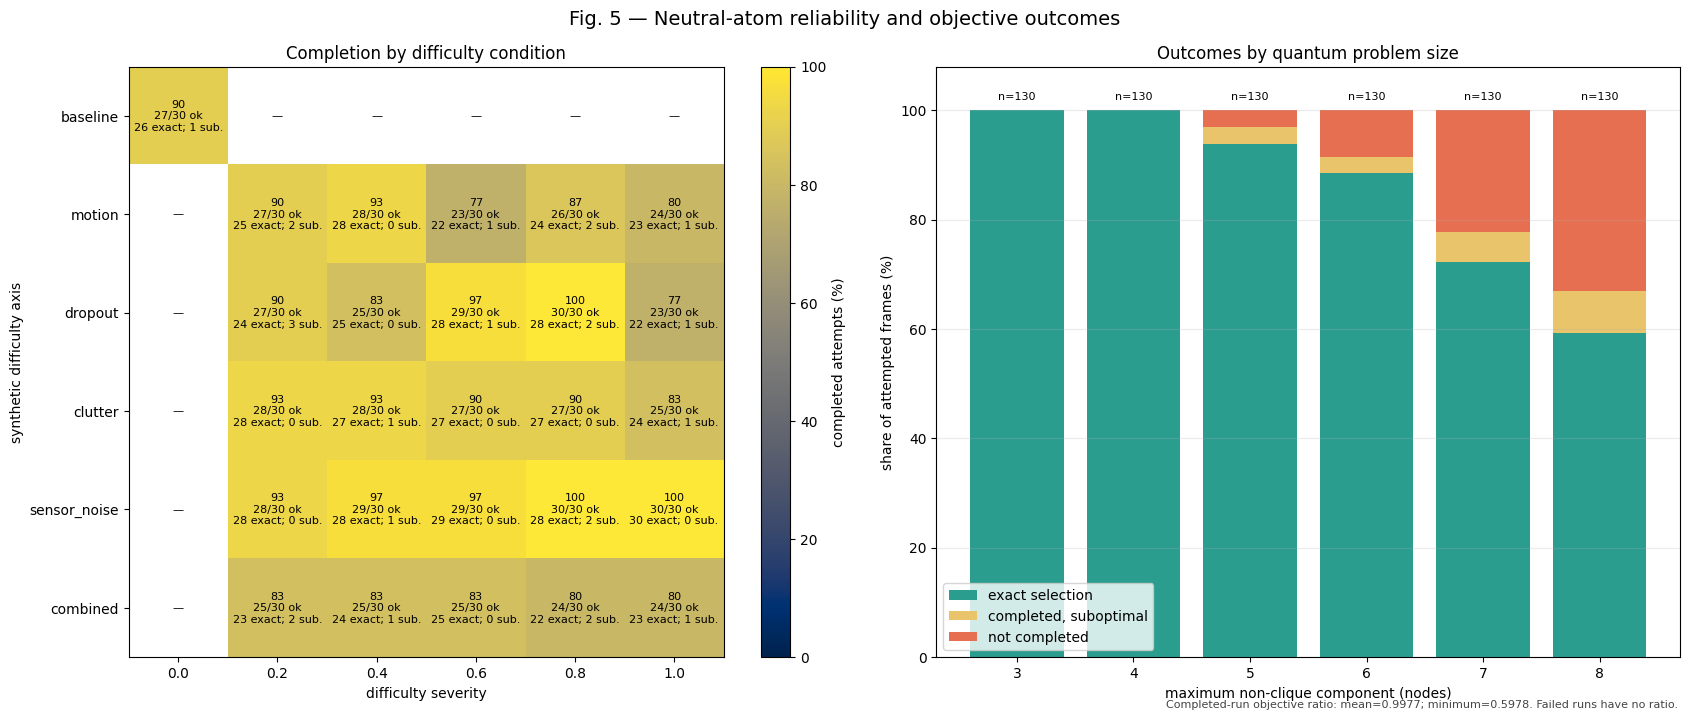

WindowsPath('C:/Projects/Summer School Challenge/Neutral-Atom-QC-for-MHT/outputs/figures/fig5_quantum_reliability.png')

In [14]:
# Fig. 5 — Show quantum completion and objective outcomes without survivor-only medians.
plot_scenarios = ("baseline", *BENCHMARK_AXES)
plot_severities = (0.0, *BENCHMARK_SEVERITIES)
prepared_benchmark_rows = [
    row for row in benchmark_records if row.get("input_fingerprint") is not None
]
attempted_quantum_rows = [
    row for row in benchmark_records if bool(row.get("quantum_attempted"))
]
successful_quantum_rows = [
    row for row in attempted_quantum_rows
    if row.get("quantum_status") == "completed"
    and row.get("relative_objective") is not None
]
completion_matrix = np.full((len(plot_scenarios), len(plot_severities)), np.nan)
completion_annotations = np.full(completion_matrix.shape, "", dtype=object)
for row_index, scenario_name in enumerate(plot_scenarios):
    for severity_index, severity in enumerate(plot_severities):
        valid_cell = (
            scenario_name == "baseline" and np.isclose(severity, 0.0)
        ) or (scenario_name != "baseline" and not np.isclose(severity, 0.0))
        if not valid_cell:
            continue
        attempts = matching_rows(
            attempted_quantum_rows, scenario_name, severity
        )
        completed = [
            row for row in attempts if row.get("quantum_status") == "completed"
        ]
        exact_matches = sum(row.get("selection_agrees") is True for row in completed)
        suboptimal = len(completed) - exact_matches
        if attempts:
            completion_matrix[row_index, severity_index] = 100.0 * len(completed) / len(attempts)
            completion_annotations[row_index, severity_index] = (
                f"{len(completed)}/{len(attempts)} ok\n"
                f"{exact_matches} exact; {suboptimal} sub."
            )

figure, (coverage_axis, size_axis) = plt.subplots(1, 2, figsize=(17, 7.2))
draw_heatmap(
    coverage_axis, completion_matrix, plot_scenarios, plot_severities,
    title="Completion by difficulty condition",
    colorbar_label="completed attempts (%)", cmap="cividis",
    vmin=0.0, vmax=100.0, value_format=".0f",
    annotations=completion_annotations,
)
coverage_axis.set_ylabel("synthetic difficulty axis")

quantum_sizes = sorted({
    int(row["maximum_nonclique_component_nodes"])
    for row in attempted_quantum_rows
})
exact_percentages, suboptimal_percentages, failure_percentages = [], [], []
size_attempt_counts = []
for size in quantum_sizes:
    attempts = [
        row for row in attempted_quantum_rows
        if int(row["maximum_nonclique_component_nodes"]) == size
    ]
    completed = [row for row in attempts if row.get("quantum_status") == "completed"]
    exact_count = sum(row.get("selection_agrees") is True for row in completed)
    suboptimal_count = len(completed) - exact_count
    failure_count = len(attempts) - len(completed)
    total = len(attempts)
    size_attempt_counts.append(total)
    exact_percentages.append(100.0 * exact_count / total)
    suboptimal_percentages.append(100.0 * suboptimal_count / total)
    failure_percentages.append(100.0 * failure_count / total)
exact_bars = size_axis.bar(
    quantum_sizes, exact_percentages, color="#2A9D8F", label="exact selection"
)
suboptimal_bars = size_axis.bar(
    quantum_sizes, suboptimal_percentages, bottom=exact_percentages,
    color="#E9C46A", label="completed, suboptimal",
)
failure_bottom = np.asarray(exact_percentages) + np.asarray(suboptimal_percentages)
failure_bars = size_axis.bar(
    quantum_sizes, failure_percentages, bottom=failure_bottom,
    color="#E76F51", label="not completed",
)
for size, total in zip(quantum_sizes, size_attempt_counts, strict=True):
    size_axis.text(size, 101.5, f"n={total}", ha="center", va="bottom", fontsize=8)
size_axis.set(
    xlabel="maximum non-clique component (nodes)",
    ylabel="share of attempted frames (%)", ylim=(0, 108),
    title="Outcomes by quantum problem size",
)
size_axis.set_xticks(quantum_sizes)
size_axis.grid(axis="y", alpha=0.25)
size_axis.legend(loc="lower left")
finite_ratios = finite_values(successful_quantum_rows, "relative_objective")
ratio_summary = (
    f"Completed-run objective ratio: mean={np.mean(finite_ratios):.4f}; "
    f"minimum={np.min(finite_ratios):.4f}. Failed runs have no ratio."
    if finite_ratios.size else "No completed quantum objective ratios."
)
figure.suptitle("Fig. 5 — Neutral-atom reliability and objective outcomes", fontsize=14)
figure.text(0.99, 0.01, ratio_summary, ha="right", fontsize=8, color="#444444")
fig5_path = finish_figure(figure, "fig5_quantum_reliability.png")
fig5_path

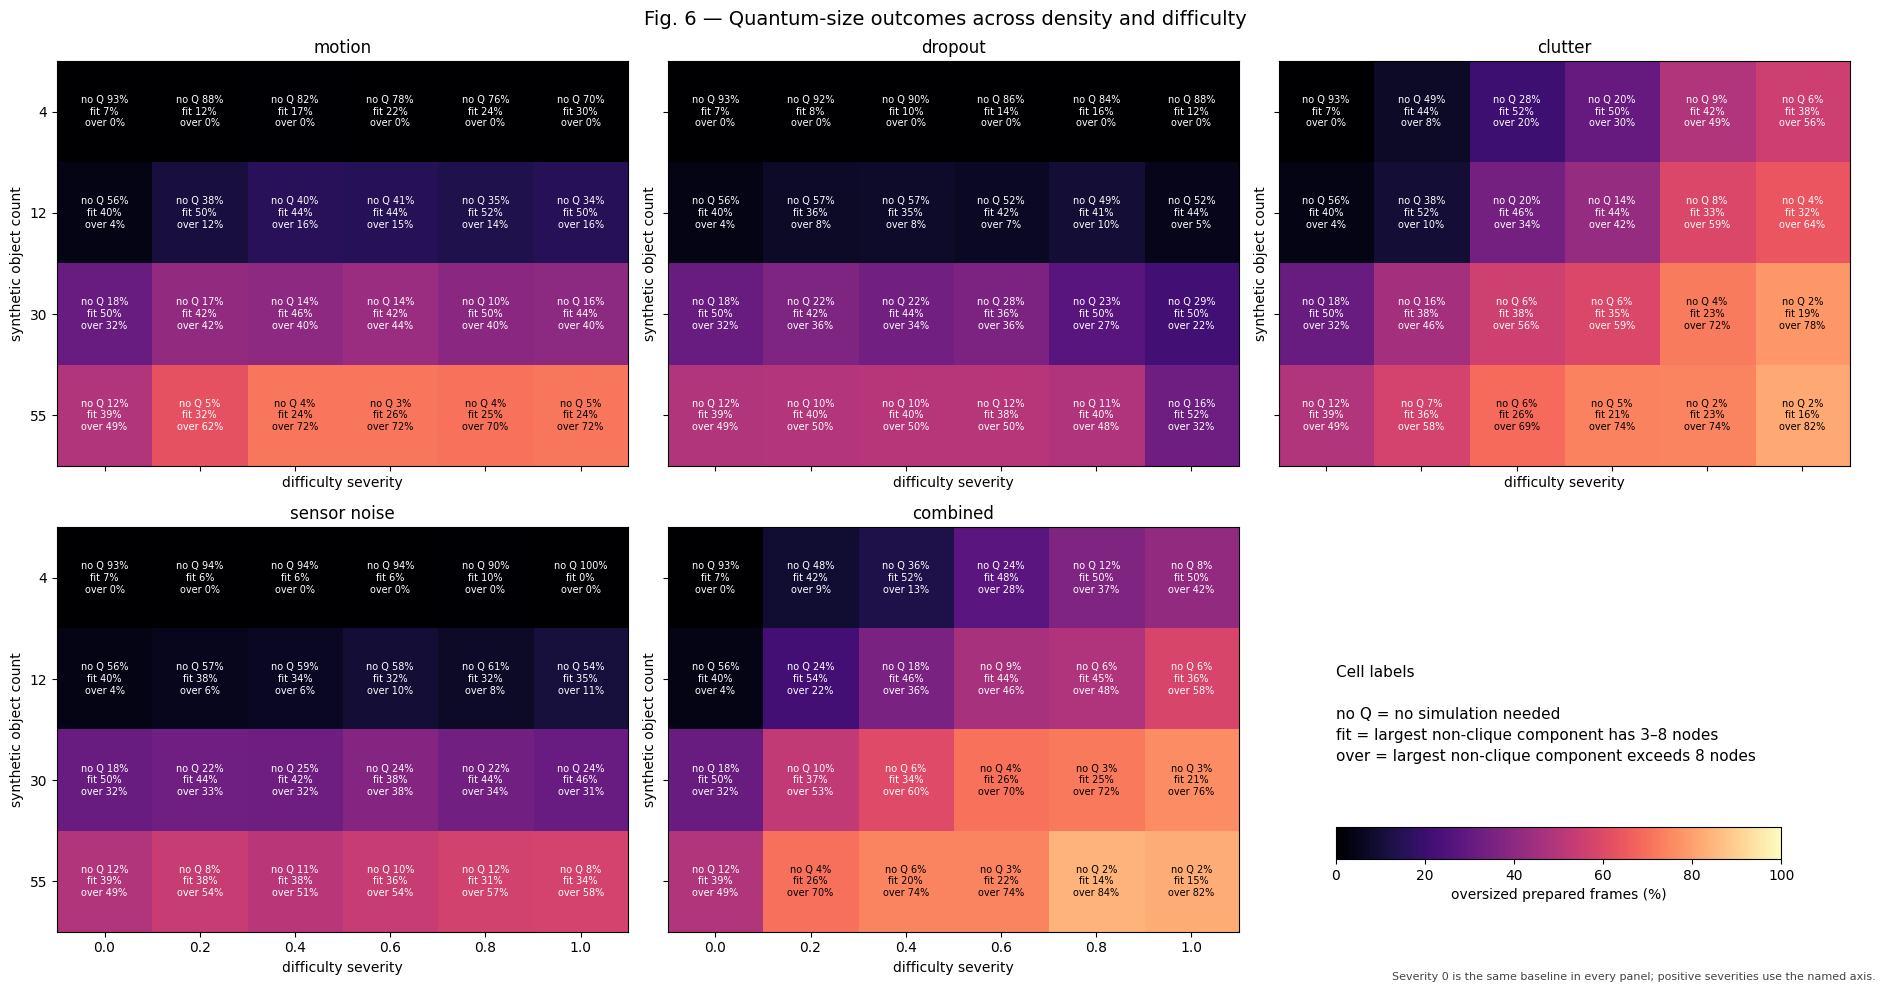

WindowsPath('C:/Projects/Summer School Challenge/Neutral-Atom-QC-for-MHT/outputs/figures/fig6_quantum_size_outcomes.png')

In [15]:
# Fig. 6 — Separate no-work, supported, and oversized frames for every axis.
figure, outcome_axes = plt.subplots(2, 3, figsize=(19, 10), sharex=True, sharey=True)
active_outcome_axes = []
outcome_image = None
for panel_index, difficulty_axis in enumerate(BENCHMARK_AXES):
    panel = outcome_axes.flat[panel_index]
    active_outcome_axes.append(panel)
    oversized_matrix = np.full(
        (len(BENCHMARK_OBJECT_COUNTS), len(plot_severities)), np.nan
    )
    outcome_annotations = np.full(oversized_matrix.shape, "", dtype=object)
    for object_index, object_count in enumerate(BENCHMARK_OBJECT_COUNTS):
        for severity_index, severity in enumerate(plot_severities):
            source_axis = "baseline" if np.isclose(severity, 0.0) else difficulty_axis
            rows = [
                row for row in prepared_benchmark_rows
                if row["axis"] == source_axis
                and row["object_count"] == object_count
                and np.isclose(row["severity"], severity)
            ]
            if not rows:
                continue
            sizes = [int(row["maximum_nonclique_component_nodes"]) for row in rows]
            no_work = sum(size == 0 for size in sizes)
            supported = sum(
                1 <= size <= overnight_config.quantum_max_nonclique_component_nodes
                for size in sizes
            )
            oversized = len(rows) - no_work - supported
            oversized_matrix[object_index, severity_index] = 100.0 * oversized / len(rows)
            outcome_annotations[object_index, severity_index] = (
                f"no Q {100.0 * no_work / len(rows):.0f}%\n"
                f"fit {100.0 * supported / len(rows):.0f}%\n"
                f"over {100.0 * oversized / len(rows):.0f}%"
            )
    outcome_image = panel.imshow(
        oversized_matrix, aspect="auto", cmap="magma", vmin=0.0, vmax=100.0
    )
    panel.set_title(difficulty_axis.replace("_", " "))
    panel.set_xticks(range(len(plot_severities)), plot_severities)
    panel.set_yticks(range(len(BENCHMARK_OBJECT_COUNTS)), BENCHMARK_OBJECT_COUNTS)
    panel.set_xlabel("difficulty severity")
    panel.set_ylabel("synthetic object count")
    for object_index in range(oversized_matrix.shape[0]):
        for severity_index in range(oversized_matrix.shape[1]):
            value = oversized_matrix[object_index, severity_index]
            if not np.isfinite(value):
                continue
            rgba = outcome_image.cmap(outcome_image.norm(value))
            luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            panel.text(
                severity_index, object_index,
                outcome_annotations[object_index, severity_index],
                ha="center", va="center", fontsize=7,
                color="white" if luminance < 0.48 else "black",
            )
legend_axis = outcome_axes.flat[-1]
legend_axis.axis("off")
legend_axis.text(
    0.10, 0.86,
    "Cell labels\n\n"
    "no Q = no simulation needed\n"
    "fit = largest non-clique component has 3–8 nodes\n"
    "over = largest non-clique component exceeds 8 nodes",
    va="top", fontsize=11, linespacing=1.5,
)
if outcome_image is not None:
    colorbar_axis = legend_axis.inset_axes([0.10, 0.18, 0.78, 0.08])
    figure.colorbar(
        outcome_image, cax=colorbar_axis, orientation="horizontal",
        label="oversized prepared frames (%)",
    )
figure.suptitle(
    "Fig. 6 — Quantum-size outcomes across density and difficulty", fontsize=14
)
figure.text(
    0.99, 0.01,
    "Severity 0 is the same baseline in every panel; positive severities use the named axis.",
    ha="right", fontsize=8, color="#444444",
)
fig6_path = finish_figure(figure, "fig6_quantum_size_outcomes.png")
fig6_path

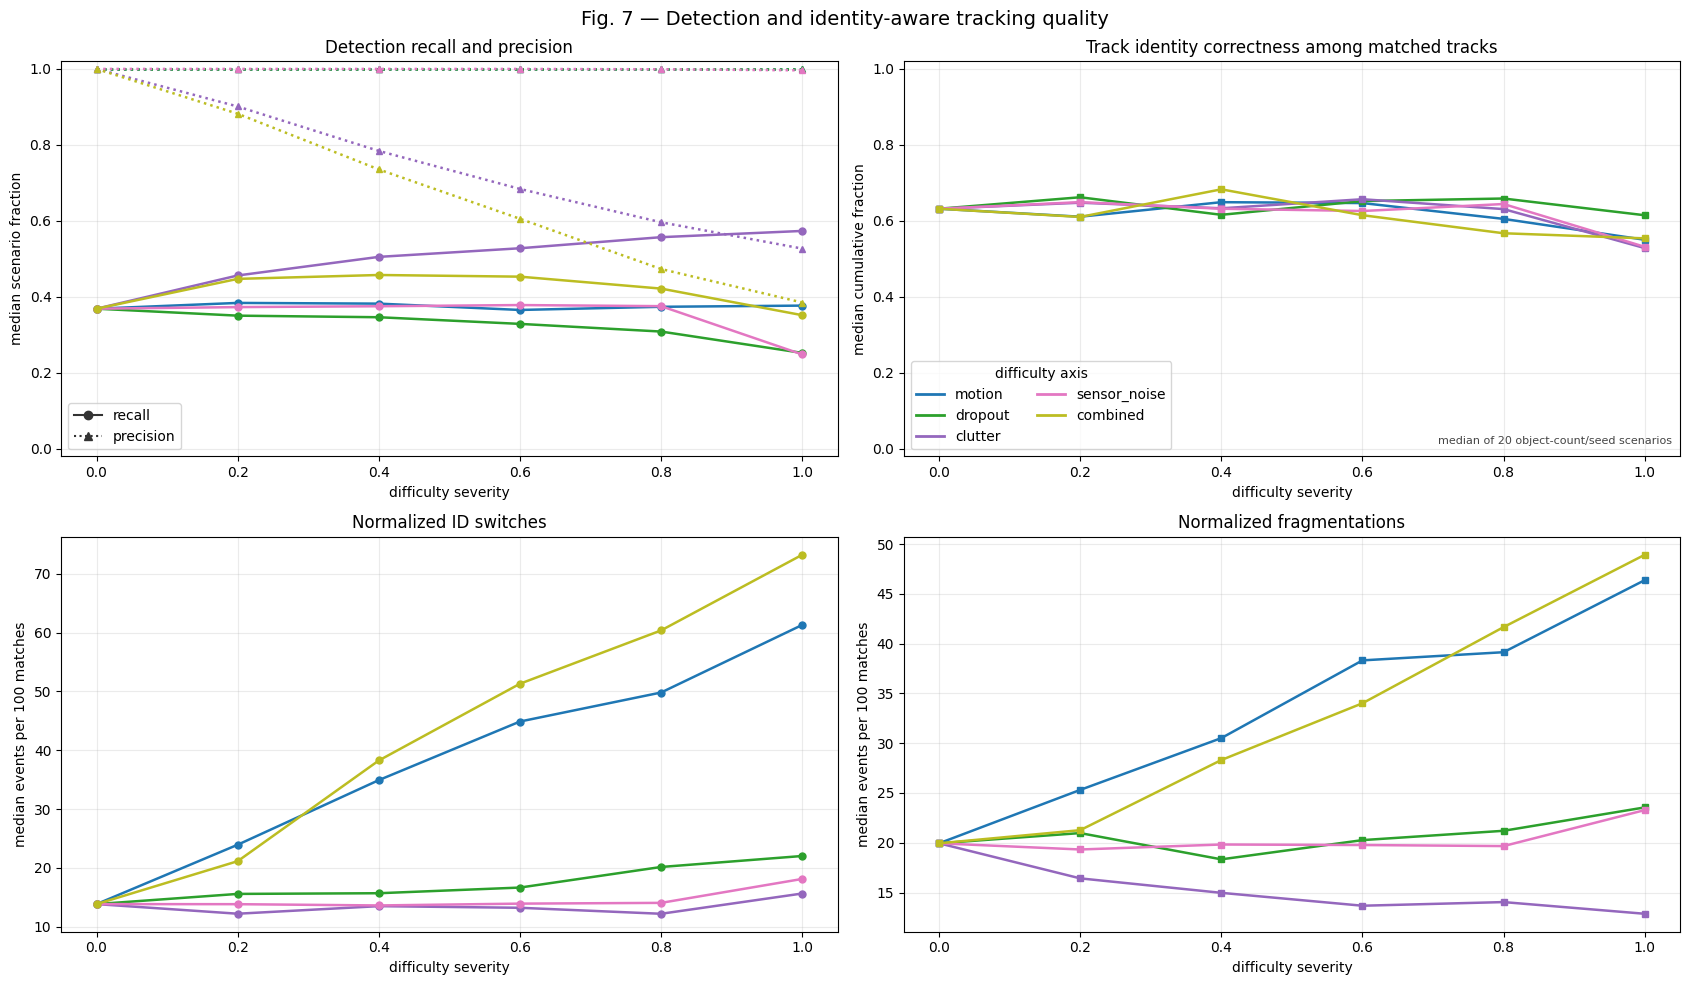

WindowsPath('C:/Projects/Summer School Challenge/Neutral-Atom-QC-for-MHT/outputs/figures/fig7_detection_and_tracking_quality.png')

In [16]:
# Fig. 7 — Scenario-level detection and normalized tracking outcomes.
colors = plt.get_cmap("tab10")(np.linspace(0.0, 0.8, len(BENCHMARK_AXES)))
tracking_rows = [
    row for row in benchmark_records
    if row.get("tracking_metrics_status") == "completed"
]
rows_by_scenario = {}
for row in tracking_rows:
    rows_by_scenario.setdefault(row["scenario"], []).append(row)
scenario_quality_rows = []
for scenario_name, rows in rows_by_scenario.items():
    rows = sorted(rows, key=lambda row: row["frame"])
    latest = rows[-1]
    matched_detections = sum(int(row["matched_detection_count"]) for row in rows)
    truth_instances = sum(int(row["ground_truth_count"]) for row in rows)
    detection_instances = sum(int(row["detection_count"]) for row in rows)
    matched_tracks = int(latest["cumulative_matched_track_gt_count"])
    correct_tracks = int(latest["cumulative_identity_correct_match_count"])
    scenario_quality_rows.append({
        "scenario": scenario_name, "axis": latest["axis"],
        "severity": latest["severity"], "object_count": latest["object_count"],
        "detection_recall": matched_detections / truth_instances if truth_instances else 1.0,
        "detection_precision": (
            matched_detections / detection_instances if detection_instances else 0.0
        ),
        "identity_correctness": (correct_tracks / matched_tracks if matched_tracks else np.nan),
        "id_switches_per_100_matches": (
            100.0 * int(latest["cumulative_id_switch_count"]) / matched_tracks
            if matched_tracks else np.nan
        ),
        "fragmentations_per_100_matches": (
            100.0 * int(latest["cumulative_fragmentation_count"]) / matched_tracks
            if matched_tracks else np.nan
        ),
    })

def condition_medians(metric_key, difficulty_axis):
    medians = []
    for severity in plot_severities:
        source_axis = "baseline" if np.isclose(severity, 0.0) else difficulty_axis
        rows = [
            row for row in scenario_quality_rows
            if row["axis"] == source_axis and np.isclose(row["severity"], severity)
        ]
        values = finite_values(rows, metric_key)
        medians.append(np.median(values) if values.size else np.nan)
    return medians

figure, quality_axes = plt.subplots(2, 2, figsize=(17, 10))
detection_axis, identity_axis, switch_axis, fragmentation_axis = quality_axes.flat
for difficulty_axis, color in zip(BENCHMARK_AXES, colors, strict=True):
    detection_axis.plot(
        plot_severities, condition_medians("detection_recall", difficulty_axis),
        color=color, linestyle="-", marker="o", linewidth=1.8, markersize=5,
    )
    detection_axis.plot(
        plot_severities, condition_medians("detection_precision", difficulty_axis),
        color=color, linestyle=":", marker="^", linewidth=1.8, markersize=5,
    )
    identity_axis.plot(
        plot_severities, condition_medians("identity_correctness", difficulty_axis),
        color=color, marker="s", linewidth=1.8, markersize=5,
    )
    switch_axis.plot(
        plot_severities, condition_medians("id_switches_per_100_matches", difficulty_axis),
        color=color, marker="o", linewidth=1.8, markersize=5,
    )
    fragmentation_axis.plot(
        plot_severities, condition_medians("fragmentations_per_100_matches", difficulty_axis),
        color=color, marker="s", linewidth=1.8, markersize=5,
    )
detection_axis.set(
    xlabel="difficulty severity", ylabel="median scenario fraction", ylim=(-0.02, 1.02),
    title="Detection recall and precision",
)
identity_axis.set(
    xlabel="difficulty severity", ylabel="median cumulative fraction", ylim=(-0.02, 1.02),
    title="Track identity correctness among matched tracks",
)
switch_axis.set(
    xlabel="difficulty severity", ylabel="median events per 100 matches",
    title="Normalized ID switches",
)
fragmentation_axis.set(
    xlabel="difficulty severity", ylabel="median events per 100 matches",
    title="Normalized fragmentations",
)
for plot_axis in quality_axes.flat:
    plot_axis.grid(alpha=0.25)
detection_axis.legend(
    handles=[
        Line2D([0], [0], color="#333333", linestyle="-", marker="o", label="recall"),
        Line2D([0], [0], color="#333333", linestyle=":", marker="^", label="precision"),
    ],
    loc="lower left",
)
axis_handles = [
    Line2D([0], [0], color=color, linewidth=2, label=difficulty_axis)
    for difficulty_axis, color in zip(BENCHMARK_AXES, colors, strict=True)
]
identity_axis.legend(
    handles=axis_handles, title="difficulty axis", ncol=2, loc="lower left"
)
figure.suptitle("Fig. 7 — Detection and identity-aware tracking quality", fontsize=14)
identity_axis.text(
    0.99, 0.03, "median of 20 object-count/seed scenarios",
    transform=identity_axis.transAxes, ha="right", fontsize=8, color="#444444",
)
fig7_path = finish_figure(figure, "fig7_detection_and_tracking_quality.png")
fig7_path

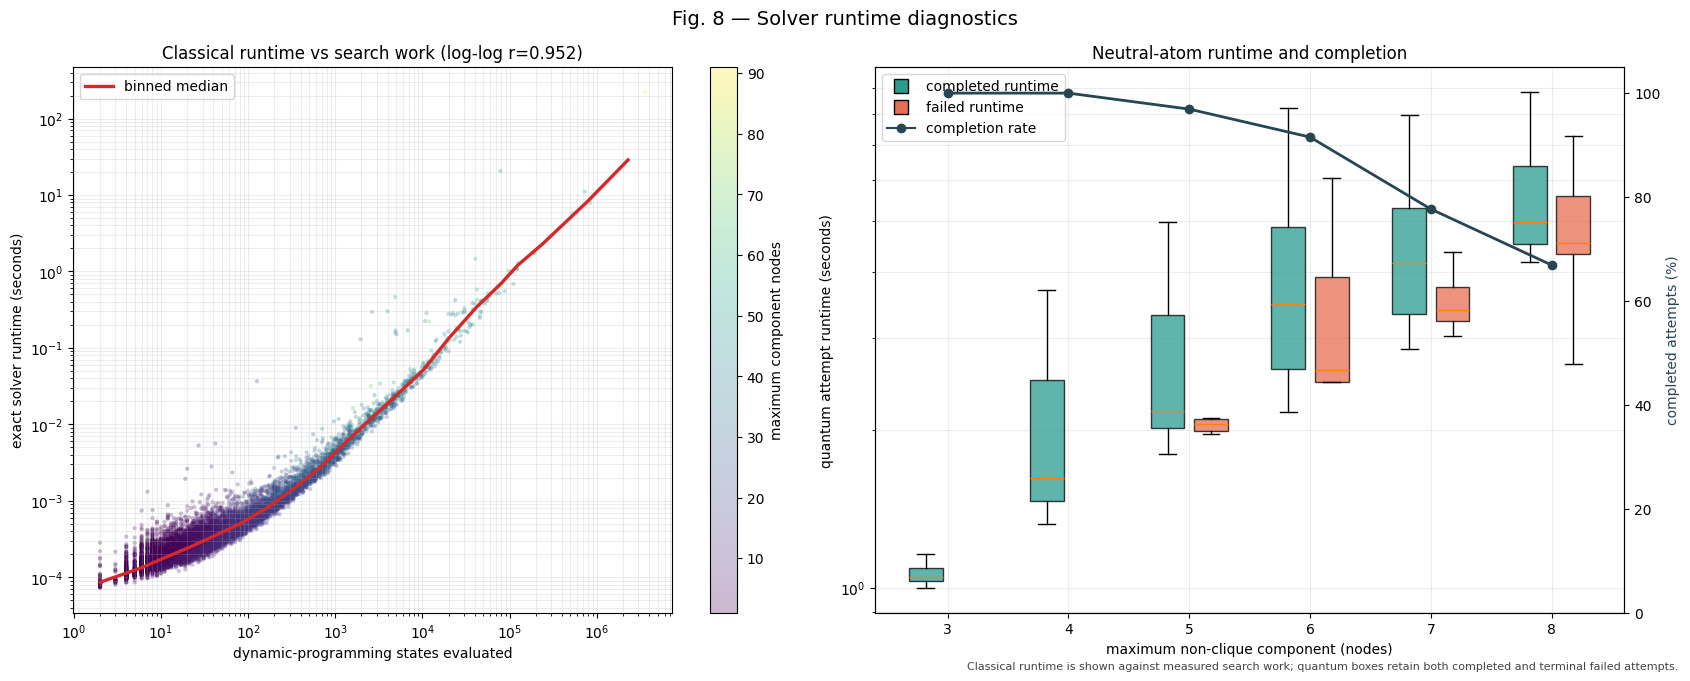

WindowsPath('C:/Projects/Summer School Challenge/Neutral-Atom-QC-for-MHT/outputs/figures/fig8_runtime_diagnostics.png')

In [17]:
# Fig. 8 — Relate runtime to actual classical search work and quantum outcomes.
figure, (classical_axis, quantum_axis) = plt.subplots(1, 2, figsize=(17, 6.8))
classical_runtime_rows = []
for row in benchmark_records:
    if row.get("exact_status") != "optimal" or row.get("exact_runtime_seconds") in (None, 0):
        continue
    diagnostics = json.loads(row.get("exact_diagnostics_json") or "{}")
    states_evaluated = diagnostics.get("states_evaluated")
    if states_evaluated is None or int(states_evaluated) < 1:
        continue
    classical_runtime_rows.append((
        int(states_evaluated), float(row["exact_runtime_seconds"]),
        int(row["maximum_component_nodes"]),
    ))
classical_states = np.asarray([item[0] for item in classical_runtime_rows], dtype=float)
classical_runtimes = np.asarray([item[1] for item in classical_runtime_rows], dtype=float)
classical_sizes = np.asarray([item[2] for item in classical_runtime_rows], dtype=float)
runtime_scatter = classical_axis.scatter(
    classical_states, classical_runtimes, c=classical_sizes, cmap="viridis",
    s=9, alpha=0.28, linewidths=0, rasterized=True,
)
if classical_states.size:
    state_bins = np.geomspace(classical_states.min(), classical_states.max(), 22)
    bin_centers, bin_medians = [], []
    for lower, upper in zip(state_bins[:-1], state_bins[1:], strict=True):
        selected = (classical_states >= lower) & (classical_states < upper)
        if np.any(selected):
            bin_centers.append(np.median(classical_states[selected]))
            bin_medians.append(np.median(classical_runtimes[selected]))
    classical_axis.plot(
        bin_centers, bin_medians, color="#D62828", linewidth=2.4,
        label="binned median",
    )
    log_correlation = np.corrcoef(
        np.log10(classical_states), np.log10(classical_runtimes)
    )[0, 1]
else:
    log_correlation = np.nan
classical_axis.set(
    xlabel="dynamic-programming states evaluated",
    ylabel="exact solver runtime (seconds)",
    title=f"Classical runtime vs search work (log-log r={log_correlation:.3f})",
)
classical_axis.set_xscale("log")
classical_axis.set_yscale("log")
classical_axis.grid(alpha=0.22, which="both")
classical_axis.legend(loc="upper left")
figure.colorbar(runtime_scatter, ax=classical_axis, label="maximum component nodes")

quantum_sizes = sorted({
    int(row["maximum_nonclique_component_nodes"])
    for row in attempted_quantum_rows
})
successful_runtime_groups = []
failed_runtime_groups = []
failed_runtime_positions = []
completion_rates = []
for size in quantum_sizes:
    attempts = [
        row for row in attempted_quantum_rows
        if int(row["maximum_nonclique_component_nodes"]) == size
    ]
    successful = finite_values(
        [row for row in attempts if row.get("quantum_status") == "completed"],
        "quantum_runtime_seconds",
    )
    failed = finite_values(
        [row for row in attempts if row.get("quantum_status") != "completed"],
        "quantum_runtime_seconds",
    )
    successful_runtime_groups.append(successful)
    if failed.size:
        failed_runtime_groups.append(failed)
        failed_runtime_positions.append(size + 0.18)
    completion_rates.append(100.0 * len(successful) / len(attempts))
successful_boxplot = quantum_axis.boxplot(
    successful_runtime_groups, positions=np.asarray(quantum_sizes) - 0.18,
    widths=0.28, patch_artist=True, manage_ticks=False, showfliers=False,
)
for box in successful_boxplot["boxes"]:
    box.set(facecolor="#2A9D8F", alpha=0.75)
if failed_runtime_groups:
    failed_boxplot = quantum_axis.boxplot(
        failed_runtime_groups, positions=failed_runtime_positions,
        widths=0.28, patch_artist=True, manage_ticks=False, showfliers=False,
    )
    for box in failed_boxplot["boxes"]:
        box.set(facecolor="#E76F51", alpha=0.75)
quantum_axis.set(
    xlabel="maximum non-clique component (nodes)",
    ylabel="quantum attempt runtime (seconds)",
    title="Neutral-atom runtime and completion",
)
quantum_axis.set_xticks(quantum_sizes)
quantum_axis.set_yscale("log")
quantum_axis.grid(alpha=0.22, which="both")
completion_axis = quantum_axis.twinx()
completion_axis.plot(
    quantum_sizes, completion_rates, color="#264653", marker="o", linewidth=2,
)
completion_axis.set_ylabel("completed attempts (%)", color="#264653")
completion_axis.set_ylim(0, 105)
quantum_axis.legend(
    handles=[
        Line2D([0], [0], marker="s", color="none", markerfacecolor="#2A9D8F", markersize=10, label="completed runtime"),
        Line2D([0], [0], marker="s", color="none", markerfacecolor="#E76F51", markersize=10, label="failed runtime"),
        Line2D([0], [0], color="#264653", marker="o", label="completion rate"),
    ],
    loc="upper left",
)
figure.suptitle("Fig. 8 — Solver runtime diagnostics", fontsize=14)
figure.text(
    0.99, 0.01,
    "Classical runtime is shown against measured search work; quantum boxes retain both "
    "completed and terminal failed attempts.",
    ha="right", fontsize=8, color="#444444",
)
fig8_path = finish_figure(figure, "fig8_runtime_diagnostics.png")
fig8_path